### PART 4 — Random Forest Regression

#### We will:

#### Train the model

#### Evaluate performance (R², RMSE)

#### Visualize predictions

#### Analyze feature importance

In [2]:
# Importing required Libraries 

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Chargement des données
X_train_fp = np.load("X_train_fp.npy")
y_train = np.load("y_train.npy")

# 2. Détection des valeurs infinies ou NaN dans y_train
mask = np.isfinite(y_train)

# 3. Garder que les données valides
X_train_clean = X_train_fp[mask]
y_train_clean = y_train[mask]

print(f"Lignes supprimées car infinies : {len(y_train) - len(y_train_clean)}")

# 4. Initialisation et entraînement du modèle (Correction ici)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_clean, y_train_clean)
print("Modèle entraîné avec succès !")


Lignes supprimées car infinies : 6
Modèle entraîné avec succès !


In [5]:
# Make prediction

X_test_fp = np.load("X_test_fp.npy")

y_pred = rf.predict(X_test_fp)

In [6]:
# Evaluate performance

# 1. Chargement des données de test
X_test_fp = np.load("X_test_fp.npy")
y_test = np.load("y_test.npy")

# 2. Créer un masque pour enlever les infinis/NaN dans y_test
mask_test = np.isfinite(y_test)

# 3. Appliquer le masque
X_test_clean = X_test_fp[mask_test]
y_test_clean = y_test[mask_test]

# 4. Faire les prédictions sur les données propres
y_pred = rf.predict(X_test_clean)

# 5. Evaluate the performance
r2 = r2_score(y_test_clean, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))

print(f"R² Score : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")


R² Score : 0.614
RMSE : 0.836


Taille de y_test_clean : 1075
Taille de y_pred : 1075


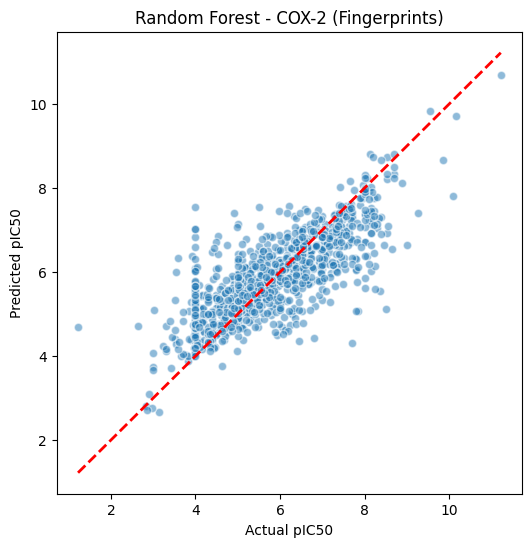

In [7]:
# Predicted vs Actual Plot

# 1. Vérification que les données de test sont propres (même étape que tout à l'heure)
mask_test = np.isfinite(y_test)
y_test_clean = y_test[mask_test]
# y_pred a normalement déjà été généré sur X_test[mask_test]

# 2. Vérification de sécurité avant de tracer
print(f"Taille de y_test_clean : {len(y_test_clean)}")
print(f"Taille de y_pred : {len(y_pred)}")

# 3. Tracer le graphique
plt.figure(figsize=(6,6))
plt.scatter(y_test_clean, y_pred, alpha=0.5, edgecolors='w')
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Random Forest - COX-2 (Fingerprints)")

# 4. Ligne de référence (Diagonale)
limit = [min(y_test_clean), max(y_test_clean)]
plt.plot(limit, limit, color='red', linestyle='--', linewidth=2)

plt.show()


In [8]:
# Cross-Validation (More Reliable) 

from sklearn.model_selection import KFold, cross_val_score

# 1. Recharger les données complètes
X_all = np.load("X_fp.npy")
y_all = np.load("y.npy")

# 2. Nettoyer les valeurs infinies/NaN (TRÈS IMPORTANT pour ne pas faire planter le CV)
mask = np.isfinite(y_all)
X_clean = X_all[mask]
y_clean = y_all[mask]

# 3. On définit un mélangeur (Shuffle) pour casser l'ordre des données
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Lancer la Cross-Validation sur les données propres
cv_scores = cross_val_score(rf, X_clean, y_clean, cv=kf, scoring='r2')

print("Scores par pli (fold) :", cv_scores)
print("CV R² Moyenne :", round(cv_scores.mean(), 3))
print("CV R² Écart-type :", round(cv_scores.std(), 3))

Scores par pli (fold) : [0.56984639 0.61607444 0.57401389 0.60559858 0.58728551]
CV R² Moyenne : 0.591
CV R² Écart-type : 0.018
